In [1]:
#import required classes and packages
import os
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt   
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import pickle
from keras.utils.np_utils import to_categorical
from keras.layers import Dense, Dropout, Flatten
from keras.models import Sequential, load_model, Model
import pickle
from keras.callbacks import ModelCheckpoint
import random
import warnings
warnings.filterwarnings('ignore')

Using TensorFlow backend.
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [2]:
#loading and displaying IoT23 attack dataset
dataset = pd.read_csv("Dataset/kdd_data.csv")
labels = np.unique(dataset['Attack_Type'])
dataset

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,Attack_Type
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,dos
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,25,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,dos
125969,8,udp,private,SF,105,145,0,0,0,0,...,244,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,30,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,8,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,dos


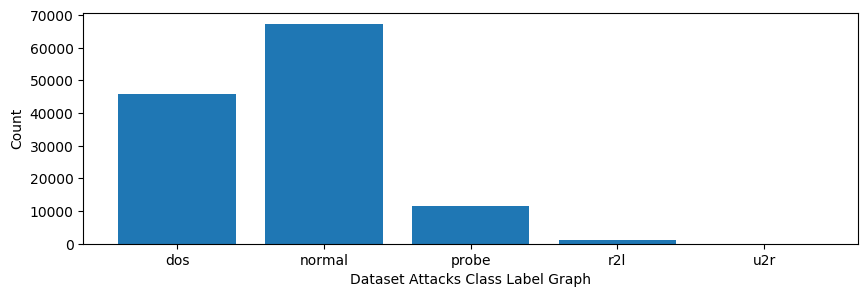

In [3]:
#visualizing different attack class labels count found in dataset
names, count = np.unique(dataset['Attack_Type'], return_counts = True)
height = count
bars = names
y_pos = np.arange(len(bars))
plt.figure(figsize = (10, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Dataset Attacks Class Label Graph")
plt.ylabel("Count")
plt.show()

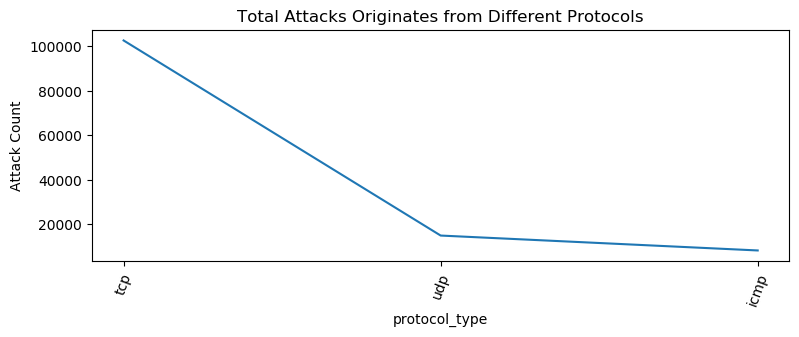

In [4]:
#graphs of different Crimes found in dataset
data = dataset.groupby(["protocol_type"])['Attack_Type' ].count().sort_values(ascending=False).reset_index(name='Attack Count').reset_index()
data = data.iloc[0:20]
plt.figure(figsize=(9, 3))
sns.lineplot(data=data, x="protocol_type", y="Attack Count")
plt.xticks(rotation=70)
plt.title("Total Attacks Originates from Different Protocols")
plt.show()

In [5]:
#applying dataset processing technique to convert non-numeric data to numeric data
label_encoder = []
columns = dataset.columns
types = dataset.dtypes.values
for j in range(len(types)):
    name = types[j]
    if name == 'object': #finding column with object type
        le = LabelEncoder()
        dataset[columns[j]] = pd.Series(le.fit_transform(dataset[columns[j]].astype(str)))#encode all str columns to numeric
        label_encoder.append([columns[j], le])
dataset.fillna(0, inplace = True)#replace missing values
dataset

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,Attack_Type
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0
3,0,1,24,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1
4,0,1,24,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,25,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0
125969,8,2,49,9,105,145,0,0,0,0,...,244,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1
125970,0,1,54,9,2231,384,0,0,0,0,...,30,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1
125971,0,1,30,5,0,0,0,0,0,0,...,8,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0


In [6]:
#dataset shuffling & Normalization
Y = dataset['Attack_Type'].ravel()
dataset.drop(['Attack_Type'], axis = 1,inplace=True)
X = dataset.values
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffle dataset values
X = X[indices]
Y = Y[indices]
print("Dataset shuffling & Normalization Completed")
print("Total number of features available in Dataset = "+str(X.shape[1]))

Dataset shuffling & Normalization Completed
Total number of features available in Dataset = 41


In [7]:
#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Train & Test Dataset Split")
print("80% records used to train algorithms : "+str(X_train.shape[0]))
print("20% records features used to test algorithms : "+str(X_test.shape[0]))

Train & Test Dataset Split
80% records used to train algorithms : 100778
20% records features used to test algorithms : 25195


In [8]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [9]:
def calculateMetrics(algorithm, predict, y_test):
    a = accuracy_score(y_test,predict)*100
    p = precision_score(y_test, predict,average='macro') * 100
    r = recall_score(y_test, predict,average='macro') * 100
    f = f1_score(y_test, predict,average='macro') * 100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  :  "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FScore    : "+str(f))    
    conf_matrix = confusion_matrix(y_test, predict) 
    plt.figure(figsize =(6, 3)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.xticks(rotation=90)
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()  

KNN Accuracy  :  96.82873586028974
KNN Precision : 57.29234027029252
KNN Recall    : 57.748958266965204
KNN FScore    : 57.507590875316104


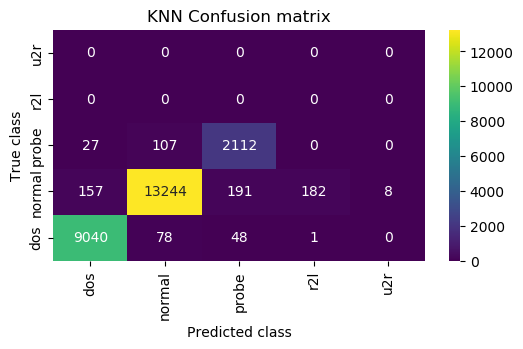

In [10]:
#training XGBoost ML algorithm on 80% training data and then evaluating performance on 20% test data
knn_cls = KNeighborsClassifier(algorithm="ball_tree")
#training on train data
knn_cls.fit(X_train[0:1000], y_train[0:1000])
#perfrom prediction on test data
predict = knn_cls.predict(X_test)
#call function to calculate aaccuracy and other metrics
calculateMetrics("KNN", y_test, predict)


ANN Accuracy  :  97.39630879142686
ANN Precision : 68.53885163436047
ANN Recall    : 72.28043347776614
ANN FScore    : 70.2187224243034


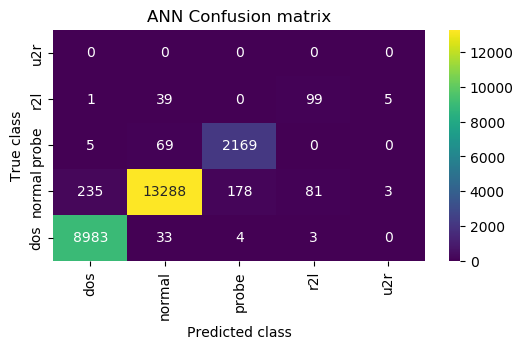

In [11]:
y_train1 = to_categorical(y_train)
y_test1 = to_categorical(y_test)
#training ANN algorithm with below mention number of layers and neurons
ann_model = Sequential()
#adding ANN dense layer with 32 neurons to filter dataset 32 times
ann_model.add(Dense(32, input_shape=(X_train.shape[1],)))
ann_model.add(Dense(16, activation = 'relu'))
ann_model.add(Dense(y_train1.shape[1], activation = 'softmax'))
ann_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
#now train and load the model
if os.path.exists("model/ann_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/ann_weights.hdf5', verbose = 1, save_best_only = True)
    ann_model.fit(X_train, y_train1, batch_size = 32, epochs = 10, validation_data=(X_test, y_test1), callbacks=[model_check_point], verbose=1)
else:
    ann_model.load_weights("model/ann_weights.hdf5")
predict = ann_model.predict(X_test)
predict = np.argmax(predict, axis=1)
#call function to calculate aaccuracy and other metrics
calculateMetrics("ANN", y_test, predict)

In [ ]:
#defining variables to save best ABC selected model with tuned parameters
best_model = None
best_features = None
ann_model = Sequential()
best_neurons = []

In [12]:
#defining fitness function to calculate ANN accuracy with different number of features, epoch and leraning rate
def fitnessFunction(features, train_x, train_y, test_x, test_y, neurons, num_epochs):    
    global ann_model, best_neurons
    best_neurons = neurons
    ann_model.add(Dense(neurons[0], input_shape=(X_train[:, features].shape[1],)))
    ann_model.add(Dense(neurons[1], activation = 'relu'))
    ann_model.add(Dense(y_train1.shape[1], activation = 'softmax'))
    ann_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    ann_model.fit(train_x[:, features], train_y, batch_size = 32, epochs = num_epochs, validation_data=(test_x[:, features], test_y), verbose=1)
    predict = ann_model.predict(test_x[:, features])
    predict = np.argmax(predict, axis=1)
    true_label = np.argmax(test_y, axis=1)
    fitness = accuracy_score(true_label, predict)
    return fitness 

In [13]:
#ABC will choose random population as number of features and then calculate fitness function to choose best
#parameters. This process will continue till ABC dont find any more optimum fitness value
def ABCOptimization(population_size, max_iterations):
    global best_model, best_features
    best = None
    #choose random population
    population = [random.sample(range(X_train.shape[1]), int(X_train.shape[1] * 0.8)) for _ in range(population_size)]
    for _ in range(max_iterations):
        #calculate fitness
        fitness_values = [fitnessFunction(features, X_train, y_train1, X_test, y_test1, [64, 32], 4) for features in population]
        #continue seelcting optimized features till ABC find no more optimization
        for i in range(population_size):
            new_features = population[i].copy()
            new_features[random.randint(0, len(new_features) - 1)] = random.randint(0, X.shape[1] - 1)
            if fitnessFunction(new_features, X_train, y_train1, X_test, y_test1, [64, 32], 10) > fitness_values[i]:
                best_features = new_features
                best_model = ann_model
                best = fitness_values[i]
                break
        if best is not None:
            break

Total features found in dataset = 41
ABC selected number of features = 32
ABC Best Number of Epochs = 10
ABC Best Learning Rate = 0.001
ABC Best Selected Neurons = [64 32]
ANN with ABC Accuracy  :  99.0633062115499
ANN with ABC Precision : 87.1501686498375
ANN with ABC Recall    : 89.59367811185362
ANN with ABC FScore    : 88.29916148336159


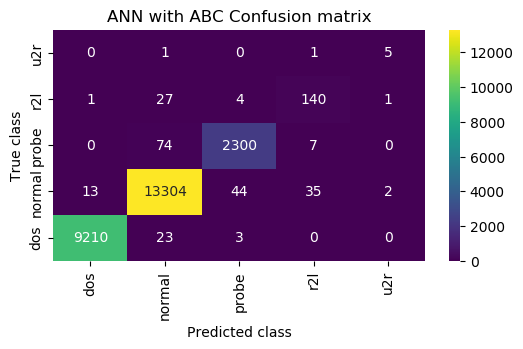

In [14]:
#trainining ANN algorithm with ABC optimization algorithm
def ANNOptimization(population_size, max_iterations):
    global best_features, best_model, best_neurons
    if os.path.exists("model/abc_ann_weights.h5"):
        data = np.load("model/data.npy", allow_pickle=True)
        best_features = data[0]
        best_neurons = data[1]
        best_epoch = data[2]
        best_lr = data[3]        
        best_model = Sequential()
        best_model.add(Dense(best_neurons[0], input_shape=(X_train[:, best_features].shape[1],)))
        best_model.add(Dense(best_neurons[1], activation = 'relu'))
        best_model.add(Dense(y_train1.shape[1], activation = 'softmax'))
        best_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
        best_model.load_weights("model/abc_ann_weights.h5")        
    else:
        ABCOptimization(population_size, max_iterations)
        best_model.save_weights("model/abc_ann_weights.h5")
        data = np.asarray([np.asarray(best_features),np.asarray(best_neurons), 10, 0.001])
        np.save("model/data", data)
        data = np.load("model/data.npy", allow_pickle=True)
        best_features = data[0]
        best_model = load_model("model/abc_ann_weights.h5")
        best_neurons = data[1]
        best_epoch = data[2]
        best_lr = data[3]
    return best_features, best_model, best_neurons, best_epoch, best_lr
best_features, best_model, best_neurons, best_epoch, best_lr = ANNOptimization(3, 10)
predict = best_model.predict(X_test[:, best_features])
predict = np.argmax(predict, axis=1)
print("Total features found in dataset = "+str(X.shape[1]))
print("ABC selected number of features = "+str(len(best_features)))
print("ABC Best Number of Epochs = "+str(best_epoch))
print("ABC Best Learning Rate = "+str(best_lr))
print("ABC Best Selected Neurons = "+str(best_neurons))
#call function to calculate aaccuracy and other metrics
calculateMetrics("ANN with ABC", y_test, predict)

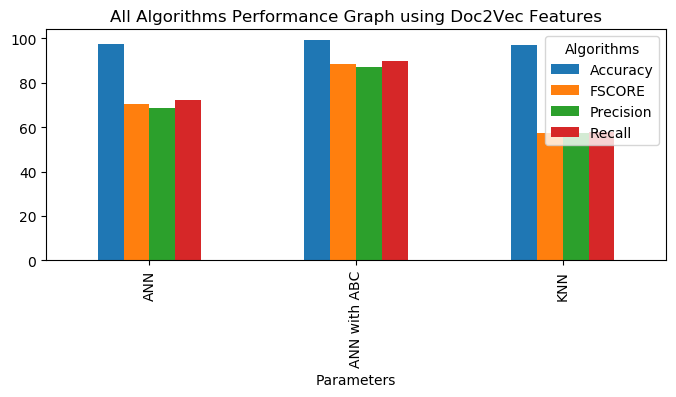

In [38]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['KNN','Accuracy',accuracy[0]],['KNN','Precision',precision[0]],['KNN','Recall',recall[0]],['KNN','FSCORE',fscore[0]],
                   ['ANN','Accuracy',accuracy[1]],['ANN','Precision',precision[1]],['ANN','Recall',recall[1]],['ANN','FSCORE',fscore[1]],
                   ['ANN with ABC','Accuracy',accuracy[2]],['ANN with ABC','Precision',precision[2]],['ANN with ABC','Recall',recall[2]],['ANN with ABC','FSCORE',fscore[2]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 3))
plt.title("All Algorithms Performance Graph using Doc2Vec Features")
plt.show()

In [16]:
#display all algorithm performnace
algorithms = ['KNN', 'ANN', 'ANN with ABC']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,KNN,96.828736,57.292340,57.748958,57.507591
1,ANN,97.396309,68.538852,72.280433,70.218722
2,ANN with ABC,99.063306,87.150169,89.593678,88.299161


In [39]:
#defining flask block code to start web page
from flask import Flask, render_template, request, redirect, url_for, session,send_from_directory

In [40]:
app = Flask(__name__)
app.secret_key = 'welcome'

In [41]:
@app.route('/PredictAction', methods=['GET', 'POST'])
def PredictAction():
    if request.method == 'POST':
        global labels, scaler
        test_dataset = pd.read_csv("Dataset/testData.csv")
        data = test_dataset.values
        for i in range(len(label_encoder)-1):
            le = label_encoder[i]
            if le[0] != 'label':
                test_dataset[le[0]] = pd.Series(le[1].transform(test_dataset[le[0]].astype(str)))#encode all str columns to numeric
        test_dataset.fillna(0, inplace = True)
        test_dataset = test_dataset.values
        test_dataset = scaler.transform(test_dataset)
        best_features, best_model, best_neurons, best_epoch, best_lr = ANNOptimization(3, 10)
        predict = best_model.predict(test_dataset[:, best_features])
        predict = np.argmax(predict, axis=1)
        output = '<table border=1 align=center width=100%><tr><th><font size="3" color="black">Test Data</th>'
        output += '<th><font size="3" color="black">Prediction Status</th></tr>'
        for i in range(len(predict)):
            output += '<tr><td><font size="3" color="black">'+str(data[i])+'</td>'
            if labels[predict[i]] == 'normal':
                output += '<td><font size="3" color="green">'+labels[predict[i]]+'</font></td></tr>'
            else:
                output += '<td><font size="3" color="red">'+labels[predict[i]]+'</font></td></tr>'
        output += "</table><br/><br/><br/><br/>"      
        return render_template('index.html', data=output)

@app.route('/Predict', methods=['GET', 'POST'])
def Predict():
    return render_template('Predict.html', data='')

@app.route('/index', methods=['GET', 'POST'])
def index():
    return render_template('index.html', data='')

@app.route('/Logout')
def Logout():
    return render_template('index.html', data='')

In [42]:
if __name__ == '__main__':
    app.run()

 * Serving Flask app '__main__' (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [04/Mar/2025 15:38:02] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [04/Mar/2025 15:38:05] "GET /index HTTP/1.1" 200 -
127.0.0.1 - - [04/Mar/2025 15:38:05] "GET /static/style.css HTTP/1.1" 304 -
127.0.0.1 - - [04/Mar/2025 15:38:05] "GET /static/images/investor.jpg HTTP/1.1" 304 -
127.0.0.1 - - [04/Mar/2025 15:38:05] "GET /static/images/back.jpg HTTP/1.1" 304 -
127.0.0.1 - - [04/Mar/2025 15:38:05] "GET /static/images/img03.jpg HTTP/1.1" 304 -
127.0.0.1 - - [04/Mar/2025 15:38:05] "GET /static/images/img01.gif HTTP/1.1" 304 -
127.0.0.1 - - [04/Mar/2025 15:38:10] "GET /Predict HTTP/1.1" 200 -
127.0.0.1 - - [04/Mar/2025 15:38:10] "GET /static/style.css HTTP/1.1" 304 -
127.0.0.1 - - [04/Mar/2025 15:38:10] "GET /static/images/investor.jpg HTTP/1.1" 304 -
127.0.0.1 - - [04/Mar/2025 15:38:10] "GET /static/images/back.jpg HTTP/1.1" 304 -
127.0.0.1 - - [04/Mar/2025 15:38:41] "POST /PredictAction HTTP/1.1" 200 -
127.0.0.1 - - [04/Mar/2